## Embeddings preprocessing:

In [31]:
import pandas as pd
import numpy as np

# Preprocess the data
data = pd.read_csv('/dcs/22/u2243582/cs310/feature_extraction/refined-set-csv.csv')
data = data[~data['Protein_FASTA'].str.contains('X')] # remove complexes with ambiguous char in FASTA string
toDrop = ['4yx4', '1laf', '4buq', '1k22', '1hmt', '1utn', '4rux', '1bty']
data = data[~data['PDB_Code'].isin(toDrop)]
data = data.reset_index()
#display(data)
y = data['Log_binding'].to_numpy()

In [5]:
# Load protein and ligand embeddings data
protein_t6 = np.load("/dcs/22/u2243582/cs310/seq_embeddings/protein_embeddings_t6.npy")
ligand_t6 = np.load("/dcs/22/u2243582/cs310/seq_embeddings/ligand_embeddings_t6.npy")
protein_t12 = np.load("/dcs/22/u2243582/cs310/seq_embeddings/protein_embeddings_t12.npy")
ligand_t12 = np.load("/dcs/22/u2243582/cs310/seq_embeddings/ligand_embeddings_t12.npy")

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Single array of embeddings data
embeddings = np.concatenate((protein_t12, ligand_t12), axis=1) # (5059, 864)

# Scale the data so one type of embedding (protein or ligand) doesn’t dominate the model due to larger magnitude values.
scaler = StandardScaler()
scaler.fit(embeddings)
X = scaler.transform(embeddings)

# PCA
pca = PCA(0.85) # keep 80% of the variance of the data
pca.fit(X)
X = pca.transform(X)

print ("Components:", pca.n_components_ , "Total explained variance:", pca.explained_variance_ratio_.sum())
#print(pca.explained_variance_ratio_)

Components: 65 Total explained variance: 0.8515733
[0.19326577 0.12001765 0.06512135 0.03781238 0.03374086 0.02822817
 0.02451734 0.02082883 0.01867036 0.01680063 0.01594606 0.01373487
 0.01269145 0.01131468 0.01098062 0.01025487 0.0093028  0.00895211
 0.00868653 0.00795926 0.00779939 0.00724218 0.00707735 0.00657464
 0.0064536  0.00628634 0.00617623 0.00584193 0.0055328  0.0055138
 0.00518497 0.00491673 0.0048825  0.00470646 0.00444971 0.00438912
 0.00420791 0.00419672 0.00404477 0.0040019  0.00392243 0.00369687
 0.00363215 0.00355975 0.00350319 0.00337324 0.00326701 0.00324287
 0.00318755 0.00317311 0.00307488 0.00294292 0.00285872 0.00280339
 0.00277388 0.00268642 0.00264614 0.0025461  0.0025169  0.00243701
 0.00239076 0.00234368 0.00228298 0.00223173 0.00217401]


In [33]:
print(type(X),type(y),X.shape,y.shape)

<class 'numpy.ndarray'> <class 'numpy.ndarray'> (5059, 65) (5059,)


## Random forest nested CV

In [34]:
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

cv_outer = KFold(n_splits=5, shuffle=True, random_state=1)

# Store metrics across folds
pearsonCoeffs = []
pearsonPValues = []
spearmanCoeffs = []
spearmanPValues = []
maeScores = []
varianceScores = []
r2Scores = []


for train_ix, test_ix in cv_outer.split(X): # outer CV

    X_train, X_test = X[train_ix, :], X[test_ix, :]
    y_train, y_test = y[train_ix], y[test_ix]

    cv_inner = KFold(n_splits=3, shuffle=True, random_state=1) # inner CV

    model = RandomForestRegressor(random_state=1)

    space = {
    'n_estimators': [25, 50, 100, 150, 200, 300],  
    'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
    'max_features': ['log2', 'sqrt', 1.0],
    'min_samples_leaf': [1, 5, 10, 25],
    'min_samples_split': [2, 10, 25, 50, 75, 100],
    }
    
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=space,
        n_iter=25,
        cv=cv_inner, # nested CV
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    result = search.fit(X_train, y_train) # inner CV

    best_model = result.best_estimator_ # best hyperparams from inner 3-fold CV, test on outer test subset
    
    print(result.best_params_)

    yPred = best_model.predict(X_test)

    # Pearson Correlation
    pearsonCoef, pearsonP = pearsonr(y_test, yPred)
    pearsonCoeffs.append(pearsonCoef)
    pearsonPValues.append(pearsonP)
    
    # Spearman Correlation
    spearmanCoef, spearmanP = spearmanr(y_test, yPred)
    spearmanCoeffs.append(spearmanCoef)
    spearmanPValues.append(spearmanP)
    
    # Mean Absolute Error
    mae = mean_absolute_error(y_test, yPred)
    maeScores.append(mae)
    
    # Variance of Errors
    variance = np.var(y_test - yPred)
    varianceScores.append(variance)

    # R2 (Coefficient of Determination)
    r2 = r2_score(y_test, yPred)
    r2Scores.append(r2)
    
# Calculate mean and standard deviation for each metric
metricsSummary = {
    "Pearson Correlation": (np.mean(pearsonCoeffs), np.std(pearsonCoeffs)),
    "Pearson P-value": (np.mean(pearsonPValues), np.std(pearsonPValues)),
    "Spearman Correlation": (np.mean(spearmanCoeffs), np.std(spearmanCoeffs)),
    "Spearman P-value": (np.mean(spearmanPValues), np.std(spearmanPValues)),
    "Mean Absolute Error": (np.mean(maeScores), np.std(maeScores)),
    "Variance of Errors": (np.mean(varianceScores), np.std(varianceScores)),
    "R2": (np.mean(r2Scores), np.std(r2Scores))
}

# Print metrics summary
for metric, (mean, std) in metricsSummary.items():
    print(f"{metric}: Mean = {mean}, Std = {std}")

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 1.0, 'max_depth': 90}
{'n_estimators': 300, 'min_samples_split': 25, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': 90}
{'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': 40}
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 1.0, 'max_depth': 20}
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': 70}
Pearson Correlation: Mean = 0.6929597382983295, Std = 0.018150395966619853
Pearson P-value: Mean = 5.970942143622253e-133, Std = 1.1867199958757197e-132
Spearman Correlation: Mean = 0.6874179873839632, Std = 0.022481209992050992
Spearman P-value: Mean = 7.490501130943327e-122, Std = 1.4981002261886647e-121
Mean Absolute Error: Mean = 1.1326563929410027, Std = 0.033700648599871874
Variance of Errors: Mean = 2.0390740886501324, Std = 0.10749180910858568
R2: M

In [35]:
print(pearsonCoeffs)
print(spearmanCoeffs)
print(maeScores)
print(varianceScores)
print(r2Scores)

[0.6732000576328124, 0.668914383883811, 0.7024698117312324, 0.7102599049334127, 0.709954533310379]
[0.6471455938722077, 0.6781701046720577, 0.7028474114354136, 0.7039761906045394, 0.7049506363355975]
[1.1803770940681981, 1.1642513763219626, 1.0925084264471077, 1.1165543444204402, 1.1095907234473046]
[2.164656935721703, 2.1733004716552, 1.9270972447838217, 1.9490543092149208, 1.981261481875016]
[0.436033051335474, 0.43251234400040206, 0.48043788514967956, 0.4817703604466167, 0.48485858716855823]


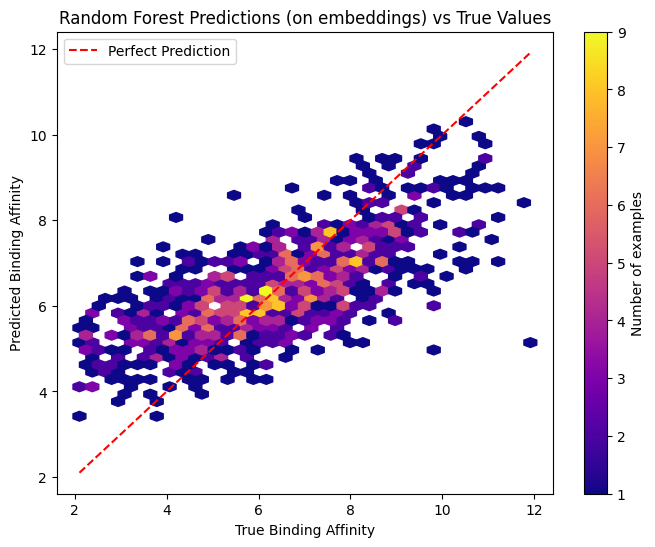

In [36]:
# Plot hexbin of true vs. predicted values
import matplotlib.pyplot as plt

# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_test, yPred, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("Random Forest Predictions (on embeddings) vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_test), min(yPred))
max_val = max(max(y_test), max(yPred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()

## SVR

In [37]:
from sklearn.svm import SVR

cv_outer = KFold(n_splits=5, shuffle=True, random_state=1)

# Store metrics across folds
pearsonCoeffs = []
pearsonPValues = []
spearmanCoeffs = []
spearmanPValues = []
maeScores = []
varianceScores = []
r2Scores = []


for train_ix, test_ix in cv_outer.split(X): # outer CV

    X_train, X_test = X[train_ix, :], X[test_ix, :]
    y_train, y_test = y[train_ix], y[test_ix]

    cv_inner = KFold(n_splits=3, shuffle=True, random_state=1)

    model = SVR()

    space = {
    "C": np.arange(2, 10, 2),
    "gamma": [0.1, 0.3, 0.5, 0.7, 0.9, 'scale', 'auto'],
    'epsilon': np.arange(0.1, 1, 0.1),
    'kernel': ['rbf']
    }
    
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=space,
        n_iter=25,
        cv=cv_inner, # nested CV
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    result = search.fit(X_train, y_train) # inner CV

    best_model = result.best_estimator_ # best hyperparams from inner 3-fold CV, test on outer test subset
    
    print(result.best_params_)

    yPred = best_model.predict(X_test)

    # Pearson Correlation
    pearsonCoef, pearsonP = pearsonr(y_test, yPred)
    pearsonCoeffs.append(pearsonCoef)
    pearsonPValues.append(pearsonP)
    
    # Spearman Correlation
    spearmanCoef, spearmanP = spearmanr(y_test, yPred)
    spearmanCoeffs.append(spearmanCoef)
    spearmanPValues.append(spearmanP)
    
    # Mean Absolute Error
    mae = mean_absolute_error(y_test, yPred)
    maeScores.append(mae)
    
    # Variance of Errors
    variance = np.var(y_test - yPred)
    varianceScores.append(variance)

    # R2 (Coefficient of Determination)
    r2 = r2_score(y_test, yPred)
    r2Scores.append(r2)
    
# Calculate mean and standard deviation for each metric
metricsSummary = {
    "Pearson Correlation": (np.mean(pearsonCoeffs), np.std(pearsonCoeffs)),
    "Pearson P-value": (np.mean(pearsonPValues), np.std(pearsonPValues)),
    "Spearman Correlation": (np.mean(spearmanCoeffs), np.std(spearmanCoeffs)),
    "Spearman P-value": (np.mean(spearmanPValues), np.std(spearmanPValues)),
    "Mean Absolute Error": (np.mean(maeScores), np.std(maeScores)),
    "Variance of Errors": (np.mean(varianceScores), np.std(varianceScores)),
    "R2": (np.mean(r2Scores), np.std(r2Scores))
}

# Print metrics summary
for metric, (mean, std) in metricsSummary.items():
    print(f"{metric}: Mean = {mean}, Std = {std}")

{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.5, 'C': 8}
{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.6, 'C': 6}
{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.30000000000000004, 'C': 2}
{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.6, 'C': 8}
{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.6, 'C': 8}
Pearson Correlation: Mean = 0.7369975463194173, Std = 0.014978398079799555
Pearson P-value: Mean = 5.073291117561896e-161, Std = 1.0142212158308833e-160
Spearman Correlation: Mean = 0.7324943398115963, Std = 0.009071468565037318
Spearman P-value: Mean = 3.89674634066854e-164, Std = 0.0
Mean Absolute Error: Mean = 1.018028515653696, Std = 0.023188542921815103
Variance of Errors: Mean = 1.7404054286485455, Std = 0.07835407448946015
R2: Mean = 0.5416083692831007, Std = 0.022325182066760072


In [38]:
print(pearsonCoeffs)
print(spearmanCoeffs)
print(maeScores)
print(varianceScores)
print(r2Scores)

[0.7418446393509894, 0.7219668941104997, 0.7167695980780122, 0.7515919708599984, 0.7528146291975868]
[0.7278601247309755, 0.7271101949073447, 0.7215321590443545, 0.7397649990644259, 0.7462042213108809]
[1.0144365365831443, 1.0531402146526738, 1.0343515658936306, 0.9981009755915129, 0.9901132855475181]
[1.7355527996760658, 1.850146622504793, 1.804419505794817, 1.6443723548881979, 1.6675358603788544]
[0.5477931291322393, 0.5182372616213085, 0.5126889859656327, 0.5626107604085331, 0.5667117092877901]


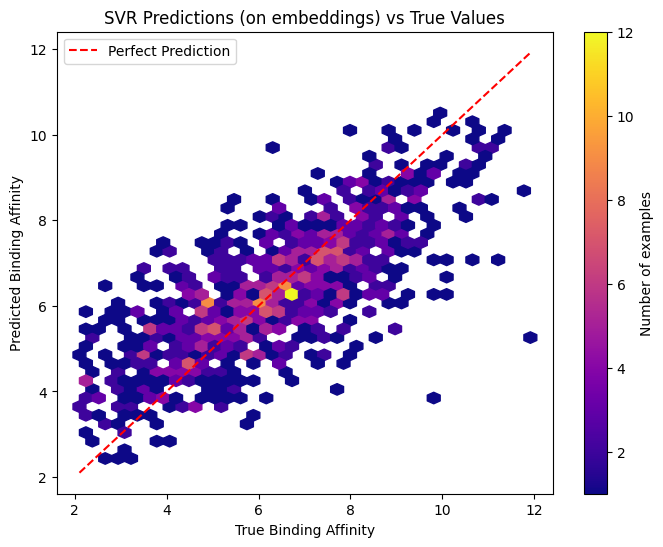

In [39]:
# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_test, yPred, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("SVR Predictions (on embeddings) vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_test), min(yPred))
max_val = max(max(y_test), max(yPred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()

## XGBoost

In [40]:
from xgboost import XGBRegressor

cv_outer = KFold(n_splits=5, shuffle=True, random_state=1)

# Store metrics across folds
pearsonCoeffs = []
pearsonPValues = []
spearmanCoeffs = []
spearmanPValues = []
maeScores = []
varianceScores = []
r2Scores = []


for train_ix, test_ix in cv_outer.split(X): # outer CV

    X_train, X_test = X[train_ix, :], X[test_ix, :]
    y_train, y_test = y[train_ix], y[test_ix]

    cv_inner = KFold(n_splits=3, shuffle=True, random_state=1)

    model = XGBRegressor(random_state=1)

    space = {
        'max_depth': [3, 6, 9, 15],
        'learning_rate': [0.1, 0.3, 0.5, 0.7, 0.9],
        'colsample_bytree': [0.5, 1],  
        'gamma': [0, 0.5, 1, 10],   
        'reg_alpha': [0, 0.5, 1, 10],
        'reg_lambda': [1, 0.5, 10],
        'subsample': [0.1, 0.5, 0.7, 1]
    }
    
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=space,
        n_iter=25,
        cv=cv_inner, # nested CV
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    result = search.fit(X_train, y_train) # inner CV

    best_model = result.best_estimator_ # best hyperparams from inner 3-fold CV, test on outer test subset
    
    print(result.best_params_)

    yPred = best_model.predict(X_test)

    # Pearson Correlation
    pearsonCoef, pearsonP = pearsonr(y_test, yPred)
    pearsonCoeffs.append(pearsonCoef)
    pearsonPValues.append(pearsonP)
    
    # Spearman Correlation
    spearmanCoef, spearmanP = spearmanr(y_test, yPred)
    spearmanCoeffs.append(spearmanCoef)
    spearmanPValues.append(spearmanP)
    
    # Mean Absolute Error
    mae = mean_absolute_error(y_test, yPred)
    maeScores.append(mae)
    
    # Variance of Errors
    variance = np.var(y_test - yPred)
    varianceScores.append(variance)

    # R2 (Coefficient of Determination)
    r2 = r2_score(y_test, yPred)
    r2Scores.append(r2)
    
# Calculate mean and standard deviation for each metric
metricsSummary = {
    "Pearson Correlation": (np.mean(pearsonCoeffs), np.std(pearsonCoeffs)),
    "Pearson P-value": (np.mean(pearsonPValues), np.std(pearsonPValues)),
    "Spearman Correlation": (np.mean(spearmanCoeffs), np.std(spearmanCoeffs)),
    "Spearman P-value": (np.mean(spearmanPValues), np.std(spearmanPValues)),
    "Mean Absolute Error": (np.mean(maeScores), np.std(maeScores)),
    "Variance of Errors": (np.mean(varianceScores), np.std(varianceScores)),
    "R2": (np.mean(r2Scores), np.std(r2Scores))
}

# Print metrics summary
for metric, (mean, std) in metricsSummary.items():
    print(f"{metric}: Mean = {mean}, Std = {std}")

/dcs/22/u2243582/.local/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/dcs/22/u2243582/.local/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain

{'subsample': 0.5, 'reg_lambda': 10, 'reg_alpha': 10, 'max_depth': 15, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1}
{'subsample': 0.5, 'reg_lambda': 1, 'reg_alpha': 0.5, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.5}
{'subsample': 0.5, 'reg_lambda': 10, 'reg_alpha': 1, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 1}
{'subsample': 1, 'reg_lambda': 10, 'reg_alpha': 1, 'max_depth': 6, 'learning_rate': 0.5, 'gamma': 0, 'colsample_bytree': 0.5}
{'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 10, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1}
Pearson Correlation: Mean = 0.6885552163009524, Std = 0.022413676782120473
Pearson P-value: Mean = 1.0640467942383547e-128, Std = 2.1058951162344152e-128
Spearman Correlation: Mean = 0.6796073298237112, Std = 0.02301334514551963
Spearman P-value: Mean = 8.699454975758384e-124, Std = 1.7397628304735672e-123
Mean Absolute Error: Mean = 1.1108779270529758, Std = 

In [41]:
print(pearsonCoeffs)
print(spearmanCoeffs)
print(maeScores)
print(varianceScores)
print(r2Scores)

[0.6924846338776164, 0.6607946153116101, 0.7086021855753805, 0.6647886783427807, 0.7161059683973741]
[0.675225562706272, 0.6594585450743679, 0.7067472669288075, 0.6510729086688374, 0.7055323657402711]
[1.120471522365163, 1.155018558784907, 1.058956757920533, 1.1474626833977906, 1.0724801127964854]
[2.001438581014433, 2.1677807876137742, 1.8467840566249267, 2.158206801031854, 1.8916584673845247]
[0.4785048953615242, 0.43330426559490975, 0.5021026370312609, 0.42631849032276226, 0.5083604545678451]


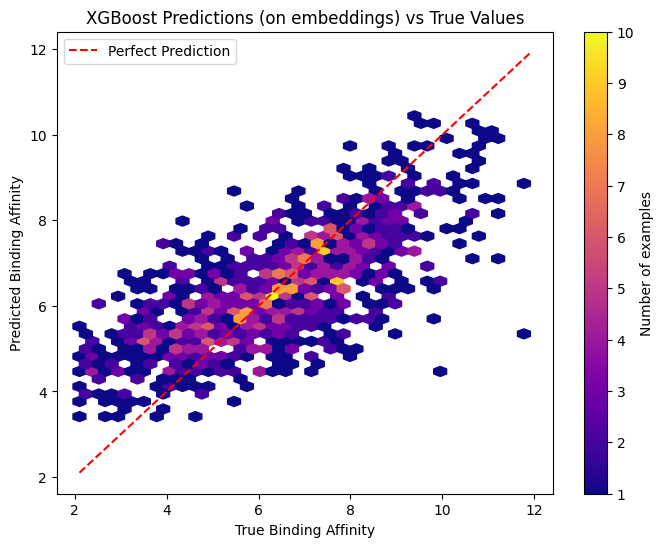

In [42]:
# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_test, yPred, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("XGBoost Predictions (on embeddings) vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_test), min(yPred))
max_val = max(max(y_test), max(yPred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()